# Model Comparison

This notebook compares the planned classical models in two modes:

- `holdout`: one grouped train/test split by `user_id`
- `cross_validation`: grouped cross-validation as a separate comparison view

The goal is to make it very obvious:

- which model wins
- by which primary metric
- how large the gain is
- what tradeoff exists in training time and stability


In [1]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import ml.compare as compare_module
from ml.features import find_latest_raw_csv, load_dataset_preview

compare_module = importlib.reload(compare_module)
run_model_comparison = compare_module.run_model_comparison

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 220)

DEFAULT_RAW_CSV = find_latest_raw_csv(REPO_ROOT / 'data' / 'raw')
DEFAULT_PROCESSED_ROOT = REPO_ROOT / 'data' / 'processed'
DEFAULT_RANDOM_SEED = 42
DEFAULT_CV_FOLDS = 5

class NotebookProgress:
    def __init__(self, title, accent='#16a34a'):
        self.title = title
        self.accent = accent
        self.handle = display(HTML(''), display_id=True)

    def update(self, payload):
        step = payload.get('step', 0)
        total = payload.get('total', 1)
        stage = payload.get('stage', '')
        message = payload.get('message', '')
        timestamp = payload.get('timestamp', '')
        percent = int(round((step / total) * 100)) if total else 100
        html = f'''<div style="border:1px solid #cbd5e1;border-radius:14px;padding:16px 18px;margin:8px 0;background:#ffffff;color:#0f172a;box-shadow:0 1px 2px rgba(15,23,42,0.06);">\n  <div style="font-weight:800;font-size:15px;margin-bottom:10px;color:#0f172a;">{self.title}</div>\n  <div style="height:12px;background:#e2e8f0;border-radius:999px;overflow:hidden;">\n    <div style="height:100%;width:{percent}%;background:linear-gradient(90deg,{self.accent},#06b6d4);transition:width 0.35s ease;"></div>\n  </div>\n  <div style="margin-top:10px;font-family:monospace;font-size:12px;color:#334155;">[{step}/{total}] {stage}</div>\n  <div style="margin-top:6px;font-size:14px;color:#0f172a;">{message}</div>\n  <div style="margin-top:6px;color:#64748b;font-size:12px;">{timestamp}</div>\n</div>'''
        self.handle.update(HTML(html))

def run_comparison_mode(evaluation_mode='holdout', cv_folds=DEFAULT_CV_FOLDS, raw_csv_path=DEFAULT_RAW_CSV, random_seed=DEFAULT_RANDOM_SEED):
    title = 'Holdout Comparison Progress' if evaluation_mode == 'holdout' else 'Cross-Validation Comparison Progress'
    accent = '#2563eb' if evaluation_mode == 'holdout' else '#ea580c'
    progress = NotebookProgress(title=title, accent=accent)
    return run_model_comparison(
        raw_csv_path=raw_csv_path,
        processed_root=DEFAULT_PROCESSED_ROOT,
        random_seed=random_seed,
        evaluation_mode=evaluation_mode,
        cv_folds=cv_folds,
        progress_callback=progress.update,
    )

def task_primary_metric(task):
    return 'pr_auc' if task == 'classification' else 'mae'

def task_metric_column(result_df, task):
    base = task_primary_metric(task)
    if base in result_df.columns:
        return base
    return f'{base}_mean'

def task_fit_column(result_df):
    return 'fit_seconds' if 'fit_seconds' in result_df.columns else 'fit_seconds_mean'

def winner_row(result_df, task):
    metric_col = task_metric_column(result_df, task)
    ascending = task == 'regression'
    return result_df.sort_values(metric_col, ascending=ascending).iloc[0]

def display_summary_table(summary):
    row_counts = summary.get('row_counts', {})
    rows = [
        {'field': 'mode', 'value': summary.get('evaluation_mode', '')},
        {'field': 'classifier winner', 'value': summary.get('classifier_winner', '')},
        {'field': 'regressor winner', 'value': summary.get('regressor_winner', '')},
        {'field': 'classifier metric', 'value': summary.get('classifier_primary_metric', '')},
        {'field': 'regressor metric', 'value': summary.get('regressor_primary_metric', '')},
        {'field': 'loaded rows', 'value': row_counts.get('loaded', '')},
        {'field': 'cleaned rows', 'value': row_counts.get('cleaned', '')},
    ]
    if 'train' in row_counts:
        rows.append({'field': 'train rows', 'value': row_counts.get('train', '')})
    if 'test' in row_counts:
        rows.append({'field': 'test rows', 'value': row_counts.get('test', '')})
    if 'cv_folds_effective' in summary:
        rows.append({'field': 'cv folds', 'value': summary.get('cv_folds_effective', '')})
    display(pd.DataFrame(rows))

def display_winner_cards(result, title):
    classifier_df = result['classifier_results']
    regressor_df = result['regressor_results']
    classifier_metric_col = task_metric_column(classifier_df, 'classification')
    regressor_metric_col = task_metric_column(regressor_df, 'regression')
    classifier_best = winner_row(classifier_df, 'classification')
    regressor_best = winner_row(regressor_df, 'regression')
    html = f'''<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(320px,1fr));gap:16px;margin:12px 0 18px 0;">\n  <div style="border:1px solid #bfdbfe;background:#ffffff;border-radius:16px;padding:18px;color:#0f172a;box-shadow:0 1px 2px rgba(37,99,235,0.10);">\n    <div style="font-size:12px;color:#1d4ed8;text-transform:uppercase;font-weight:800;letter-spacing:0.04em;">{title} Classifier Winner</div>\n    <div style="font-size:28px;font-weight:800;margin-top:10px;color:#0f172a;line-height:1.2;">{classifier_best['model_name']}</div>\n    <div style="margin-top:12px;font-size:14px;color:#334155;">Primary metric <b>{classifier_metric_col}</b>: {float(classifier_best[classifier_metric_col]):.6f}</div>\n    <div style="margin-top:6px;font-size:14px;color:#334155;">Fit time: {float(classifier_best[task_fit_column(classifier_df)]):.3f}s</div>\n  </div>\n  <div style="border:1px solid #fed7aa;background:#ffffff;border-radius:16px;padding:18px;color:#0f172a;box-shadow:0 1px 2px rgba(234,88,12,0.10);">\n    <div style="font-size:12px;color:#c2410c;text-transform:uppercase;font-weight:800;letter-spacing:0.04em;">{title} Regressor Winner</div>\n    <div style="font-size:28px;font-weight:800;margin-top:10px;color:#0f172a;line-height:1.2;">{regressor_best['model_name']}</div>\n    <div style="margin-top:12px;font-size:14px;color:#334155;">Primary metric <b>{regressor_metric_col}</b>: {float(regressor_best[regressor_metric_col]):.6f}</div>\n    <div style="margin-top:6px;font-size:14px;color:#334155;">Fit time: {float(regressor_best[task_fit_column(regressor_df)]):.3f}s</div>\n  </div>\n</div>'''
    display(HTML(html))

def plot_metric_bars(result_df, task, title):
    metric_col = task_metric_column(result_df, task)
    ascending = task == 'regression'
    frame = result_df.sort_values(metric_col, ascending=ascending).reset_index(drop=True)
    best_value = float(frame.iloc[0][metric_col])
    colors = ['#2563eb' if i == 0 else '#93c5fd' for i in range(len(frame))] if task == 'classification' else ['#ea580c' if i == 0 else '#fdba74' for i in range(len(frame))]
    fig, ax = plt.subplots(figsize=(10, 4.8))
    bars = ax.barh(frame['model_name'], frame[metric_col].astype(float), color=colors)
    for bar, value in zip(bars, frame[metric_col].astype(float)):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f' {value:.6f}', va='center', ha='left', fontsize=10)
    subtitle = 'Higher is better' if task == 'classification' else 'Lower is better'
    ax.set_title(f'{title}\n{subtitle}', fontsize=13, fontweight='bold')
    ax.set_xlabel(metric_col)
    ax.grid(axis='x', alpha=0.2)
    if task == 'regression':
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    return best_value

def plot_time_tradeoff(result_df, task, title):
    metric_col = task_metric_column(result_df, task)
    fit_col = task_fit_column(result_df)
    fig, ax = plt.subplots(figsize=(8, 5.5))
    x = result_df[fit_col].astype(float)
    y = result_df[metric_col].astype(float)
    colors = ['#2563eb', '#64748b', '#0f766e'] if task == 'classification' else ['#ea580c', '#64748b', '#7c3aed']
    ax.scatter(x, y, s=140, c=colors[:len(result_df)], alpha=0.9)
    for _, row in result_df.iterrows():
        ax.annotate(row['model_name'], (float(row[fit_col]), float(row[metric_col])), textcoords='offset points', xytext=(8, 6), fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(fit_col)
    ax.set_ylabel(metric_col)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

def plot_cv_stability(fold_df, task, title):
    metric_col = task_primary_metric(task)
    fig, ax = plt.subplots(figsize=(10, 5))
    for model_name, group in fold_df.groupby('model_name'):
        ax.plot(group['fold_index'], group[metric_col].astype(float), marker='o', linewidth=2, label=model_name)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric_col)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

print('Repo root:', REPO_ROOT)
print('Default raw CSV:', DEFAULT_RAW_CSV)


Repo root: C:\Users\nayut\OneDrive\Документы\osu-skill-predictor
Default raw CSV: C:\Users\nayut\OneDrive\Документы\osu-skill-predictor\data\raw\osu_country_try_data_full_20260601T074107Z\osu_country_try_data_v1.csv


In [2]:
raw_preview = load_dataset_preview(DEFAULT_RAW_CSV, n_rows=5)
display(Markdown(f'**Raw CSV:** `{DEFAULT_RAW_CSV.relative_to(REPO_ROOT)}`'))
display(raw_preview)


**Raw CSV:** `data\raw\osu_country_try_data_full_20260601T074107Z\osu_country_try_data_v1.csv`

,row_id,score_id,user_id,beatmap_id,beatmapset_id,ruleset,collected_at,score_created_at,score_source,seed_country_code,seed_country_rank,seed_country_player_rank,seed_global_rank,target_passed,target_accuracy,score_rank,mods_raw,observed_pp,observed_max_combo,count_300,count_100,count_50,count_miss,user_pp,user_global_rank,user_country_rank,user_accuracy,user_play_count,user_play_time_sec,user_total_hits,user_maximum_combo,beatmap_star_rating,beatmap_bpm,beatmap_ar,beatmap_od,beatmap_cs,beatmap_hp,beatmap_hit_length_sec,beatmap_total_length_sec,beatmap_count_circles,beatmap_count_sliders,beatmap_count_spinners,beatmap_status,beatmap_passcount,beatmap_playcount
0,5019360540,5019360540,4175698,5258382,2401111,osu,2026-06-01T08:26:36Z,2026-05-02T18:53:54Z,best,US,1,1,7,True,97.0340,S,NC,1775.17,2427,1849,76,8,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,7.02593,190.00,9.5,9.2,4.0,5.0,238,260,1682,251,0,ranked,16908,182260
1,4934854295,4934854295,4175698,5211120,2191876,osu,2026-06-01T08:26:36Z,2025-11-08T00:54:22Z,best,US,1,1,7,True,98.4942,S,DT,1630.13,644,476,11,0,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,7.12841,200.00,9.7,9.5,4.3,5.0,58,59,393,94,0,ranked,17180,144559
2,4888133395,4888133395,4175698,5065131,2353052,osu,2026-06-01T08:26:36Z,2025-08-13T16:46:40Z,best,US,1,1,7,True,97.5970,A,NC,1608.47,2175,2502,87,4,1,27431.8,7,1,97.1255,408850,11150983,61251422,3661,6.73248,200.00,9.5,9.1,3.8,5.5,416,424,1914,679,1,ranked,8898,165331
3,4887078214,4887078214,4175698,4704022,2219231,osu,2026-06-01T08:26:36Z,2025-08-11T18:02:30Z,best,US,1,1,7,True,98.0301,S,DT,1515.03,2406,1783,48,5,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,6.34169,200.00,9.4,9.0,4.0,5.0,210,211,1598,238,0,ranked,44124,653617
4,4918857637,4918857637,4175698,5119288,2364885,osu,2026-06-01T08:26:36Z,2025-10-08T21:19:15Z,best,US,1,1,7,True,98.2456,S,DT,1464.59,1675,1221,33,0,0,27431.8,7,1,97.1255,408850,11150983,61251422,3661,6.60982,189.99,9.4,9.2,3.9,5.1,152,152,1071,182,1,ranked,30748,355825


## Holdout Mode

One grouped train/test split. Fast and directly comparable to the baseline training notebook.

In [3]:
HOLDOUT_RESULT = run_comparison_mode(evaluation_mode='holdout')
display_summary_table(HOLDOUT_RESULT['summary'])


,field,value
0,mode,holdout
1,classifier winner,HistGradientBoostingClassifier
2,regressor winner,HistGradientBoostingRegressor
3,classifier metric,pr_auc
4,regressor metric,mae
5,loaded rows,184615
6,cleaned rows,184229
7,train rows,147301
8,test rows,36928


In [4]:
display(Markdown('## Holdout Winners'))
display_winner_cards(HOLDOUT_RESULT, title='Holdout')

display(Markdown('## Holdout Classifier Table'))
display(HOLDOUT_RESULT['classifier_results'])

display(Markdown('## Holdout Regressor Table'))
display(HOLDOUT_RESULT['regressor_results'])


## Holdout Winners

## Holdout Classifier Table

,model_name,task,evaluation_mode,primary_metric_name,primary_metric_value,fit_seconds,predict_seconds,estimator_params,pr_auc,roc_auc,f1,precision,recall,positive_rate_test,predicted_positive_rate
0,HistGradientBoostingClassifier,classification,holdout,pr_auc,0.994410,1.370743,0.299877,"{'max_depth': 6, 'min_samples_leaf': 20, 'clas...",0.994410,0.766799,0.992666,0.986374,0.999038,0.985025,0.997671
1,RandomForestClassifier,classification,holdout,pr_auc,0.994238,3.834885,0.238634,"{'n_estimators': 120, 'max_depth': 20, 'min_sa...",0.994238,0.788871,0.991803,0.987411,0.996234,0.985025,0.993826
2,LogisticRegression,classification,holdout,pr_auc,0.993370,0.370248,0.087096,"{'class_weight': 'balanced', 'random_state': N...",0.993370,0.724397,0.818730,0.992443,0.696770,0.985025,0.691562


## Holdout Regressor Table

,model_name,task,evaluation_mode,primary_metric_name,primary_metric_value,fit_seconds,predict_seconds,estimator_params,mae,rmse,r2,prediction_min,prediction_max
0,HistGradientBoostingRegressor,regression,holdout,mae,3.414300,1.126247,0.132778,"{'max_depth': 6, 'min_samples_leaf': 20, 'rand...",3.414300,5.870452,0.687647,3.322250,102.603921
1,RandomForestRegressor,regression,holdout,mae,3.474767,14.671217,0.105645,"{'n_estimators': 120, 'max_depth': 20, 'min_sa...",3.474767,5.982957,0.675560,18.549253,99.985741
2,Ridge,regression,holdout,mae,3.850324,0.131476,0.022534,{'random_state': None},3.850324,6.333012,0.636484,-8.208755,117.028854


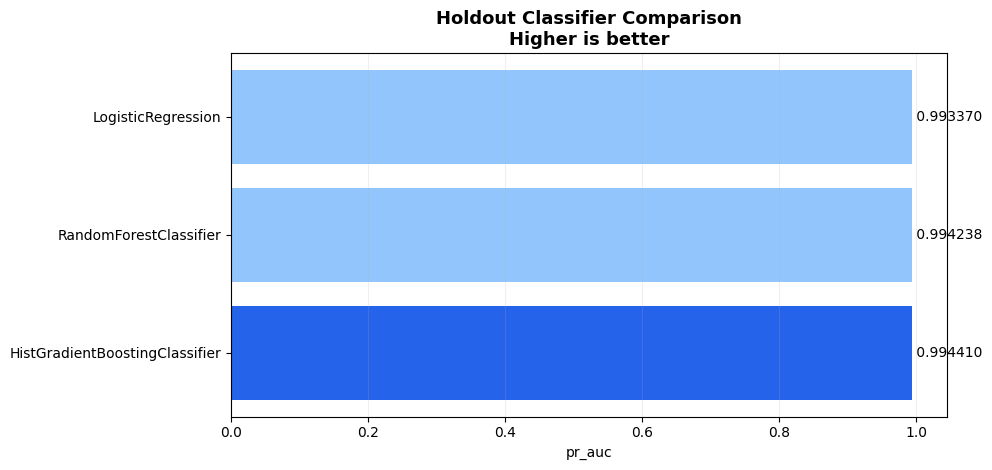

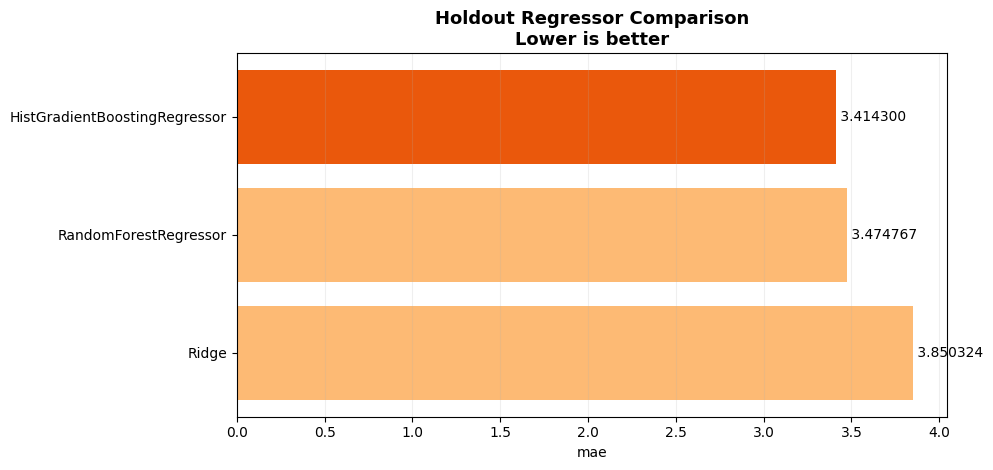

3.414299803390312

In [5]:
plot_metric_bars(HOLDOUT_RESULT['classifier_results'], task='classification', title='Holdout Classifier Comparison')
plot_metric_bars(HOLDOUT_RESULT['regressor_results'], task='regression', title='Holdout Regressor Comparison')


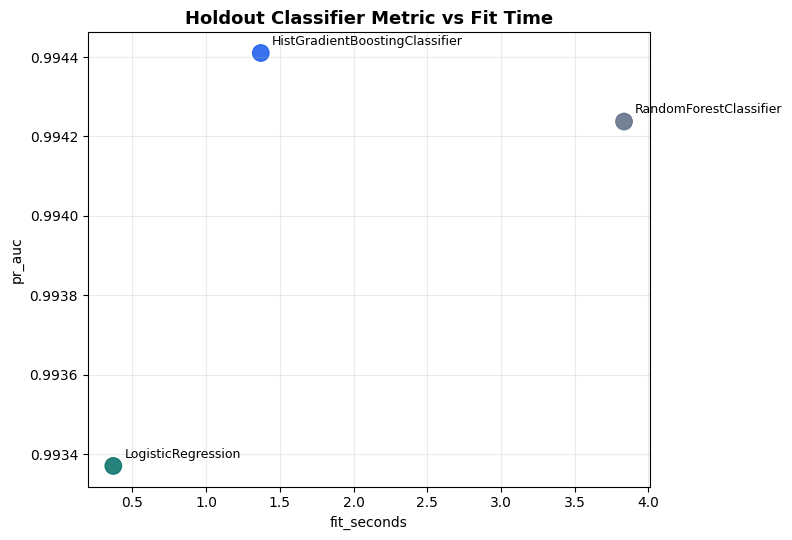

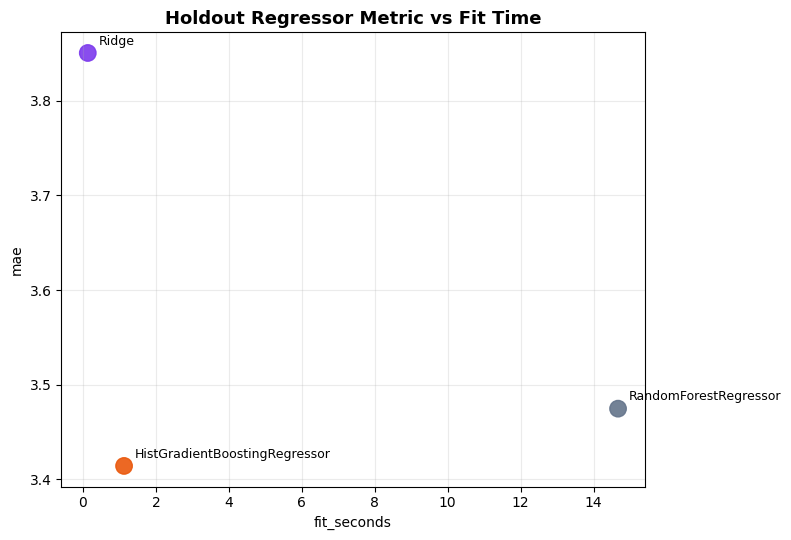

In [6]:
plot_time_tradeoff(HOLDOUT_RESULT['classifier_results'], task='classification', title='Holdout Classifier Metric vs Fit Time')
plot_time_tradeoff(HOLDOUT_RESULT['regressor_results'], task='regression', title='Holdout Regressor Metric vs Fit Time')


## Cross-Validation Mode

Separate grouped cross-validation view. This is slower, but it gives a more stable comparison than a single split.

In [7]:
CV_RESULT = run_comparison_mode(evaluation_mode='cross_validation', cv_folds=DEFAULT_CV_FOLDS)
display_summary_table(CV_RESULT['summary'])


,field,value
0,mode,cross_validation
1,classifier winner,RandomForestClassifier
2,regressor winner,HistGradientBoostingRegressor
3,classifier metric,pr_auc
4,regressor metric,mae
5,loaded rows,184615
6,cleaned rows,184229
7,cv folds,5


In [8]:
display(Markdown('## Cross-Validation Winners'))
display_winner_cards(CV_RESULT, title='Cross-Validation')

display(Markdown('## Cross-Validation Classifier Table'))
display(CV_RESULT['classifier_results'])

display(Markdown('## Cross-Validation Regressor Table'))
display(CV_RESULT['regressor_results'])


## Cross-Validation Winners

## Cross-Validation Classifier Table

,model_name,task,evaluation_mode,fold_count,primary_metric_name,primary_metric_value,estimator_params,primary_metric_value_mean,primary_metric_value_std,fit_seconds_mean,fit_seconds_std,predict_seconds_mean,predict_seconds_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,positive_rate_test_mean,positive_rate_test_std,predicted_positive_rate_mean,predicted_positive_rate_std
0,RandomForestClassifier,classification,cross_validation,5,pr_auc,0.994699,"{'n_estimators': 120, 'max_depth': 20, 'min_sa...",0.994699,0.001863,3.699890,0.082406,0.238641,0.016817,0.994699,0.001863,0.818106,0.022359,0.990531,0.001491,0.984909,0.003484,0.996226,0.000665,0.982423,0.003926,0.993710,0.000203
1,HistGradientBoostingClassifier,classification,cross_validation,5,pr_auc,0.994268,"{'max_depth': 6, 'min_samples_leaf': 20, 'clas...",0.994268,0.001713,1.349298,0.041363,0.294822,0.004204,0.994268,0.001713,0.793644,0.018040,0.991282,0.001856,0.983648,0.003887,0.999045,0.000278,0.982423,0.003926,0.997801,0.000459
2,LogisticRegression,classification,cross_validation,5,pr_auc,0.993358,"{'class_weight': 'balanced', 'random_state': N...",0.993358,0.001870,0.325421,0.033825,0.084799,0.013255,0.993358,0.001870,0.760328,0.022640,0.810130,0.009126,0.992322,0.002274,0.684579,0.013424,0.982423,0.003926,0.677764,0.014137


## Cross-Validation Regressor Table

,model_name,task,evaluation_mode,fold_count,primary_metric_name,primary_metric_value,estimator_params,primary_metric_value_mean,primary_metric_value_std,fit_seconds_mean,fit_seconds_std,predict_seconds_mean,predict_seconds_std,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,prediction_min_mean,prediction_min_std,prediction_max_mean,prediction_max_std
0,HistGradientBoostingRegressor,regression,cross_validation,5,mae,3.464400,"{'max_depth': 6, 'min_samples_leaf': 20, 'rand...",3.464400,0.085707,1.165131,0.033502,0.131185,0.004370,3.464400,0.085707,5.929703,0.225599,0.688624,0.012438,11.076053,4.132337,103.039069,0.534474
1,RandomForestRegressor,regression,cross_validation,5,mae,3.513545,"{'n_estimators': 120, 'max_depth': 20, 'min_sa...",3.513545,0.090176,14.476212,0.301858,0.122195,0.009035,3.513545,0.090176,6.059762,0.236231,0.674827,0.013243,17.665566,1.007261,99.998116,0.002910
2,Ridge,regression,cross_validation,5,mae,3.932775,{'random_state': None},3.932775,0.085245,0.143929,0.014852,0.024440,0.003704,3.932775,0.085245,6.615228,0.265139,0.611439,0.033907,-95.195601,208.963836,111.708654,2.872360


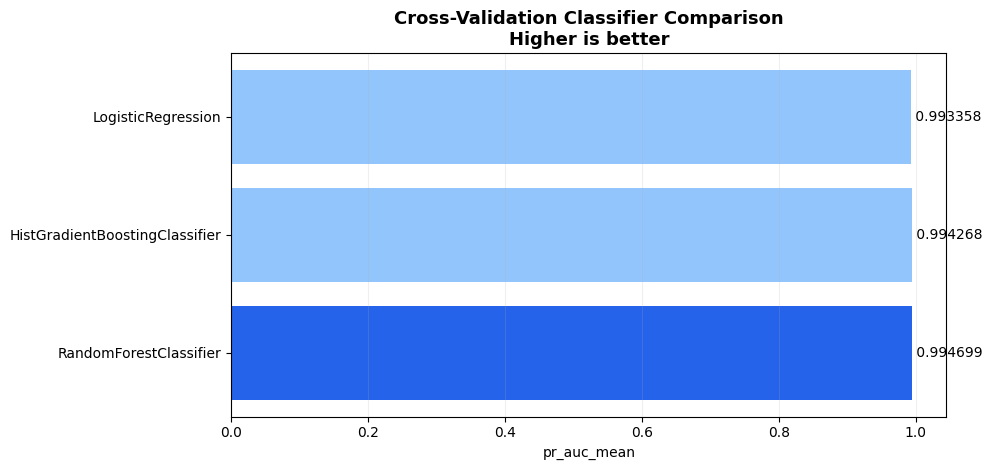

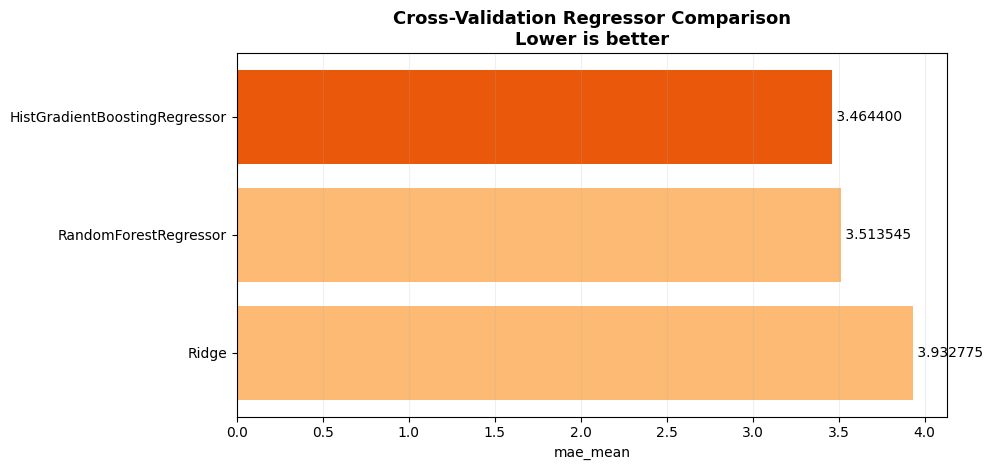

3.464399580571411

In [9]:
plot_metric_bars(CV_RESULT['classifier_results'], task='classification', title='Cross-Validation Classifier Comparison')
plot_metric_bars(CV_RESULT['regressor_results'], task='regression', title='Cross-Validation Regressor Comparison')


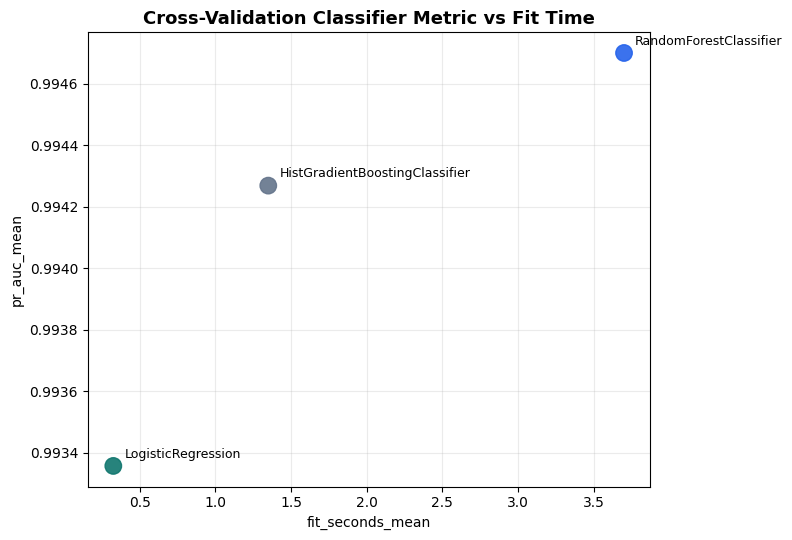

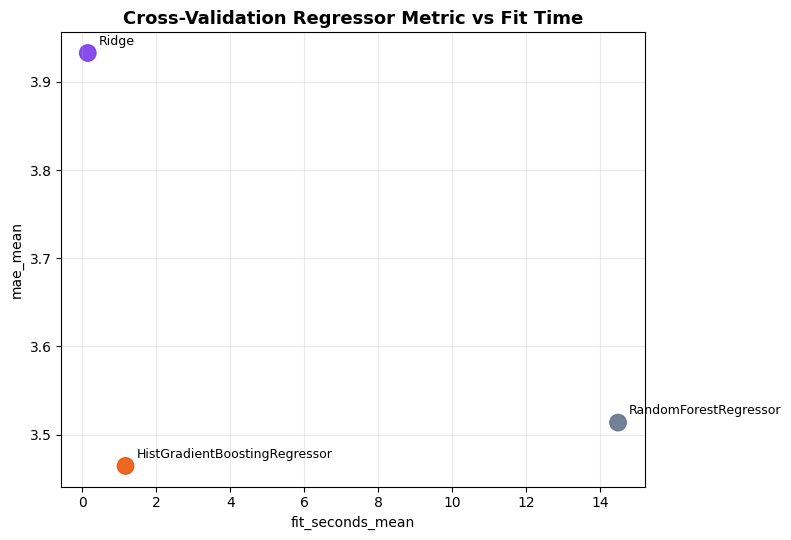

In [10]:
plot_time_tradeoff(CV_RESULT['classifier_results'], task='classification', title='Cross-Validation Classifier Metric vs Fit Time')
plot_time_tradeoff(CV_RESULT['regressor_results'], task='regression', title='Cross-Validation Regressor Metric vs Fit Time')


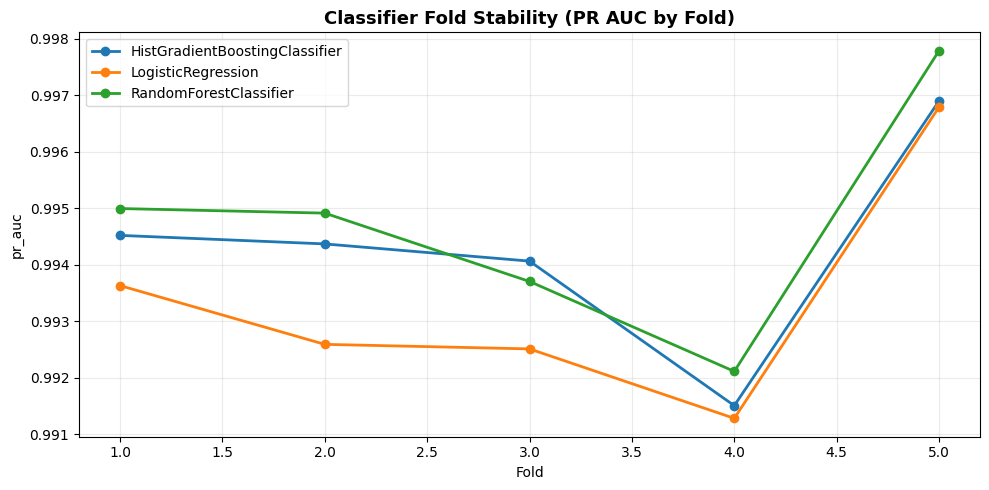

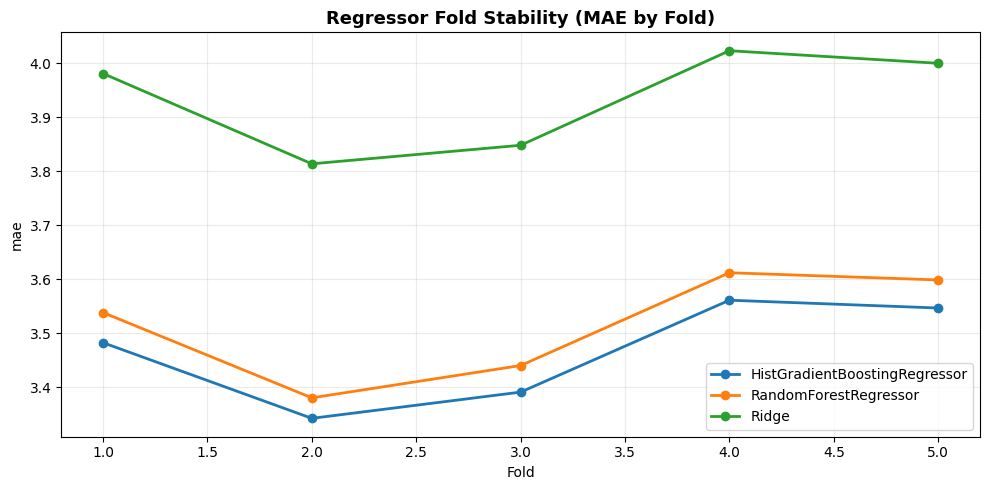

In [11]:
plot_cv_stability(CV_RESULT['classifier_fold_results'], task='classification', title='Classifier Fold Stability (PR AUC by Fold)')
plot_cv_stability(CV_RESULT['regressor_fold_results'], task='regression', title='Regressor Fold Stability (MAE by Fold)')


## Final Readout

This cell puts the holdout and cross-validation winners side by side so the final choice is easier to defend.

In [12]:
final_summary = pd.DataFrame(
    [
        {
            'mode': 'holdout',
            'classifier_winner': HOLDOUT_RESULT['summary']['classifier_winner'],
            'classifier_metric': float(winner_row(HOLDOUT_RESULT['classifier_results'], 'classification')[task_metric_column(HOLDOUT_RESULT['classifier_results'], 'classification')]),
            'regressor_winner': HOLDOUT_RESULT['summary']['regressor_winner'],
            'regressor_metric': float(winner_row(HOLDOUT_RESULT['regressor_results'], 'regression')[task_metric_column(HOLDOUT_RESULT['regressor_results'], 'regression')]),
        },
        {
            'mode': 'cross_validation',
            'classifier_winner': CV_RESULT['summary']['classifier_winner'],
            'classifier_metric': float(winner_row(CV_RESULT['classifier_results'], 'classification')[task_metric_column(CV_RESULT['classifier_results'], 'classification')]),
            'regressor_winner': CV_RESULT['summary']['regressor_winner'],
            'regressor_metric': float(winner_row(CV_RESULT['regressor_results'], 'regression')[task_metric_column(CV_RESULT['regressor_results'], 'regression')]),
        },
    ]
)
display(final_summary)


,mode,classifier_winner,classifier_metric,regressor_winner,regressor_metric
0,holdout,HistGradientBoostingClassifier,0.994410,HistGradientBoostingRegressor,3.4143
1,cross_validation,RandomForestClassifier,0.994699,HistGradientBoostingRegressor,3.4644
